<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/group_work/2026_DMUU_NetworkCapacityDesign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **💾 Before we start...... Expected Submission Format and Quality**

  1. Add group partecipants and group ID at the top of the notebook.

  2. A single Google Colab Notabook self-contained (via iCorsi or shared via email). Please keep the text and codes: (1) **Oganized as described by the sub-tasks** with text and codes cells.  (2) **It must run efficiently** First and foremost, if we cannot run we cannot evaluate it. So be sure is running. Then, avoid computationally costly simulations (maximum running time for the notabook 2 hours). If a long running time is required, explain why this is needed (3) **Comment Code** add a clear commenting to the code and functions you define. It should be easy to understand without guessing.
    
  3. In the first code cell, import required libraries and set the random seed to your group number:
  ```python
  import numpy as np
  your_group_number = 0  # EXAMPLE REPLACE with 1 if your group ID is 1
  np.random.seed(your_group_number)
  ```
  4. 📌 At the End of the Notebook add **CRediT statement**



**What is a CRediT? (Contributor Roles Taxonomy):**
CRediT offers authors the opportunity to share an accurate and detailed description of their diverse contributions to the work. The role(s) of all the team members should be listed, using these relevant categories (and task):

| Term  | Definition |
| --- | --- |
| Visualization (task)  | Preparation, creation and/or presentation of the visualization/ data and results presentation, etc |
| Software and programming (task)   | Programming, implementation of the computer code and supporting algorithms;  |
| Writing - Review - Editing (task)  | Preparation, creation and/or presentation.  Critical review, commentary or revision |
| Methodology and conceptualization (task)  | Development or design of methodology; Conceptualization of a solution approach.  |

https://www.elsevier.com/researcher/author/policies-and-guidelines/credit-author-statement



### **Example**
  
**Group ID and Names (The Teletubbies)**
**Tinky-Winky:** Writing - Review - Editing (task 3 and 4).  Software and programming (task 4).
**Dipsy**: Methodology (task 2) Writing - Review - Editing(all tasks)  
**Laa-Laa:**  Software and programming (task 3) Writing - Review - Editing (all tasks)
**Poo**: Methodology and conceptualization (task).


# **Network Capacity Optimization Problem with Uncertain Loads**
### 🧭 **Context and relevance**

In this group assignment, you will take on the role of a distribution system operator (DSO) and design new network segments. As the responsible decision-maker, you will need to select a grid expansion plan that is both cost-effective and safe. This is a prototype challenge that closely resembles real problems faced by DSOs when they need to install new cables and connectors. In modern energy systems, consumers often become prosumers, meaning they can also generate electricity through technologies such as rooftop solar panels or small wind turbines. As a result, DSOs must cope with increasing uncertainty arising from distributed energy resources (DERs), including local photovoltaic generation and micro-wind turbines. Planning these grids therefore requires investment strategies that are cost-effective, scalable, and robust to uncertainty in energy demand.

This study models a simplified version of that real-life challenge. You will be asked to **design** a new low-voltage distribution segment to connect four residential demand points **minimizing investment costs while also exploring how uncertainty in demand can affect the final investment plan**.






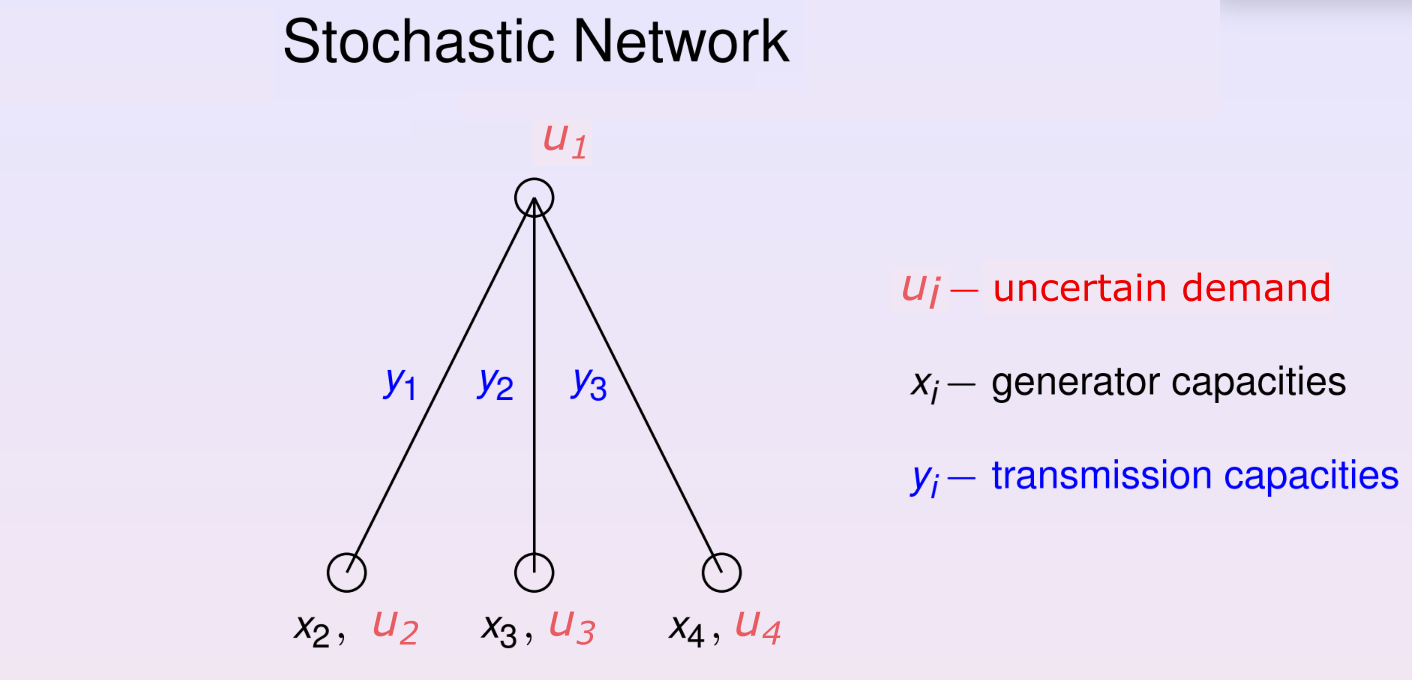


# **❓ Problem Statement:**
You, acting as the DSO, must plan an investment in 3 new cables and 3 generation units to supply 4 nodes / households.


### **🧩 Network Components  (see the figure)**
A schematic diagram illustrates the network layout. The network has 4 nodes, $i=1,2,3,4$. These are components:

- **Energy Demand $(u)$:** Each node has a non-negative energy demand, represented by the vector $$u = [u_1,u_2,u_3,u_4]^\top$$
where $u_i$ represents the energy demanded by the household on node $i$.

- **Generators ($x$):** Generation can only be installed at Nodes 2, 3, and 4. The installed generation capacities are represented by the non-negative vector $$x = [x_2,x_3,x_4]^\top,$$ where $x_i$ defines the maximum power tht can be produced at node $i$.

- **Distribution Lines ($y$):** The allowed network topology is radial, with all demand nodes connected through Node 1. The power capacities of the three distribution feeders are represented by the non-negative vector $$y = [y_1,y_2,y_3]^\top,$$ where, for instance, $y_1$ is the maximum admissible power flow between nodes 1 and 2.

###**🎯 Design Variables and Objective function:**


**Your objective is to define a reliable design for the new grid such that:**

*   the investment cost is minimized —  proportional to the capacity installed;
*   the system constraints are satisfied - also consdiering uncertain energy demand.



Let the decision variables (**the design**) be defined as:
$$
a=\begin{bmatrix}x\\y\end{bmatrix}
=
\begin{bmatrix}
x_2 & x_3 & x_4 & y_1 & y_2 & y_3
\end{bmatrix}^\top,
$$

The objective is to find the optimal $a$ such that the total investment cost is minimized. The total cost is a linear function as follows::

$$ C^\top a = \begin{bmatrix}C_{x2} & C_{x3} & C_{x4}\end{bmatrix}  \begin{bmatrix}
x_2 \\ x_3 \\ x_4 \end{bmatrix} + \begin{bmatrix} C_{y1}& C_{y2}& C_{y3}\end{bmatrix}   \begin{bmatrix}
y_1 \\ y_2 \\ y_3 \end{bmatrix},$$

where $C = [C_x, C_y] $ define the costs per unit of capacity installed [CHF/pu] on the 3 generation nodes $C_x$ and lines $C_y$.

### **🛠️ Constraints:**

A few requirements (constraints) must be sattisfied  

The total generation capacity must exceed the demand

* $ \sum_{i=2}^{4} x_i \geq \sum_{i=1}^{4} u_i$

Node 1 does not have space for a generator. Hence, we need enough in-flow capacity to sattisfy the demand:
* $y_1 + y_2 + y_3 \geq u_1 $

Each demand node must be able to meet its demand through local generation and incoming flow:
* $x_2 + y_1 \geq u_2,$
* $x_3 + y_2 \geq u_3,$
* $x_4 + y_3 \geq u_4,$


If a node has excess generation, the corresponding line must be able to carry the surplus to other nodes or to the external grid:

* $y_1 \geq  x_2- u_2, $
* $y_2 \geq  x_3 - u_3, $
* $y_3 \geq  x_4 - u_4, $

> **Note**: There are 8 inequality constraints:
- total generation capacity,
- inflow capacity at Node 1,
- demand satisfaction at Node 2,
- demand satisfaction at Node 3,
- demand satisfaction at Node 4,
- line capacity at Node 2,
- line capacity at Node 3,
- line capacity at Node 4.






### **Compact LP Formulation**

Let the decision vector be $ a \in \mathcal A$, where $\mathcal A$ is the set of feasible actions defined by the lower and upper bounds on the capacities. The deterministic design optimization problem can be written compactly as a linear program:


\begin{align*}
\min_{a\in \mathcal{A}} \quad & c^T a
\\ \text{s.t.} \quad & A_{in}a \leq b_{in}(u) \end{align*}
where:

- $c^\top=\begin{bmatrix}C_x \\ C_y\end{bmatrix}^\top$ is the vector of unit investment costs,
- $A_{in}$ is the inequality constraint matrix,
- $b_{in}(u)$ is the right-hand-side vector




> **REMARK we need an equivalent form for standard LP solvers** Many solvers, including `scipy.optimize.linprog`, use constraints of the form $
A x \le b. $  


---

More explicitly

$$
-A_{in} a=
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 1 & 1 \\
1 & 0 & 0 & 1 & 0 & 0 \\
0 & 1 & 0 & 0 & 1 & 0 \\
0 & 0 & 1 & 0 & 0 & 1 \\
-1 & 0 & 0 & 1 & 0 & 0 \\
0 & -1 & 0 & 0 & 1 & 0 \\
0 & 0 & -1 & 0 & 0 & 1
\end{bmatrix} \begin{bmatrix}
x_2 \\ x_3 \\ x_4 \\ y_1 \\ y_2 \\ y_3
\end{bmatrix}
\quad \geq
-b_{in}(u) =
\begin{bmatrix}
u_1+u_2+u_3+u_4 \\
u_1 \\
u_2 \\
u_3 \\
u_4 \\
-u_2 \\
-u_3 \\
-u_4
\end{bmatrix}.$$



* Note that $b_{in}(u)$ depends on the demand vector $u$ and can be obtained from the vector $u$ as follows $Bu$. That is, matrix multiplication with a matrix of coefficients.

$$ B=
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & -1
\end{bmatrix}
$$

###  **TASKS**

You will have to solve 4 main tasks (more details after):

1.   Solve the deterministic optimization
2.   Characterize and model the uncertainty
3.   Solve the optimization problem under uncertainty
4.   Validate and test the results, study error in the solution





* **[Task 1]** **✅Deterministic Optimal Solution of the capacity allocation problem**
Given the following data and information about the uncertainty of the system:

###*`NOMINAL DATA`* for the groups

| Group | $C_x$ | $C_y$ | nominal demand $u^{\text{nom}}$ | $x$ bounds | $y$ bounds |
|---|---|---|---|---|---|
| 1 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[0, 100]$ |
| 2 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[0, 100]$ |
| 3 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[0, 100]$ |
| 4 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[5, 100]$ |
| 5 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[0, 100]$ |
| 6 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[5, 100]$ |

---
 - **Task 1.1 - Solve the deterministic optimization problem** Use the *`NOMINAL DATA`* of your group. (a code cell)
 - **Task 1.2 - Discuss the results** : What is the optimized capacity investment $a^{\star}_{det}$ and what is the resulting cost? Are there any unbalances ("over-built" or "under-built") parts of the network? Take a guess at why this is happening. (a text cell)


In [ ]:
# Code cell for Task 1


*Discuss the results for Taks 1*



* **[Task 2]**  **🔄 Uncertainty Characterization and Modeling. Define decision-making program under uncertaity:**

  Recognize that the four loads $u$ are uncertain, hence might deviate from their nominal data. Some filed expert provided **`Additional Informaion on Uncertain Demand and Requirements`**. You will use this for **uncertainty characterization** and **uncertainty modelling**.
  
  
   - **Task 2.1 - Characterize the uncertainty** and discuss why you selected aleatoric or epistemic. Which modeling techniques are you going to use? Briefly justify your choice with a discussion. (a text cell)

   - **Task 2.2 - Qunatify the uncertainy** Write down the mathematical model you will use, explicitly. That is, an equation for the model you choose. How is this choice going to affect the decision-making problem? Discuss briefly. (a text cell)
   
   - **Task 2.3 - Define the decision-making problem**
        - Define the mathematical optimization under uncertainty. An equation for the optimization program that includes the model you defined in Task 2.2 (a text cell).
        - Then define the decision-making problem numerically ready for numerical solution in the next task. (a code cell)


### `Informaion on Uncertain Demand and Requirements`

 For Task 2, the nominal demand values from Task 1 are no longer assumed to be exact.  Each group receives additional information about how the demand may vary, but the type and amount of information differ from group to group.

---
- **Group 1**  
  Demand is uncertain, however, we do not know much yet about it. We cannot model its variability preciselly and only limited information is available. Expert judgment suggests that the true demand at each node will chance from the nominal value by an error no more than **±30%**. Worst-case scenarios are budgetted. That is, a situation where the simultaneous **±30% deviation at all nodes** occurs is unrealistic or highly unlikely. We do not have distributional information nor a PDF family. We wish to make sure the capacity constraints are always sattisfied, i.e., for all the uncertain demand scenarios considered without exceptions. Show to the experts how lower or higher budget on the worst-cases affect the solution.

---
- **Group 2**  
  Demand is uncertain, and enough quantitative information is available. For each node we know preciselly what is the **mean value of the demand** and its **standard deviation**. The mean value is equal to the nominal demand vector is $u^{\text{nom}}$ and the standard deviation at each node is assumed to be **15% of the corresponding nominal value**. We can safelly assume the shape of the probability density at each node is Gaussian and the demand at the individual nodes are uncorrelated. As an optional extension [for bouns points], you may also investigate with your model a positive correlation between the demand at the nodes could matter. The design should be chosen so that the network operates feasibly with probability at least **95%** (given the uncertianty model you selected).

---
- **Group 3**  
  Demand is uncertain, but the available information is currently very limited. Three expert suggests that the estimation error be **±10%**, **±20%** or **±30%** around the nominal demand. No further statistical information or worst-case information is provided. Your design should remain feasible under the uncertainty information provided. Show to the three experts how their estimate affect the solution.
   
---
- **Group 4**  
  Demand is uncertain, and historical data provide estimates of the **expected demand** and **standard deviation** at each node. The mean value is equal to the nominal demand vector is $u^{\text{nom}}$, and the standard deviation at each node is **10% of the corresponding nominal value**. We can safelly assume the shape of the probability density at each node is Gaussian and the demand at the individual nodes are uncorrelated. As an optional extension [for bouns points], you may also investigate with your model a positive correlation between the demand at the nodes could matter. The design should satisfy the network constraints with probability at least **97%** (given the uncertianty model you selected).

---
- **Group 5**  
  Demand is uncertain. The filed operator instead of a compact text description of the uncertainty provided **100 demand mesurements**. These samples can be interpreted as realizations of the true uncertain demand. Hence, you can choose how to use these **100 samples from the true load distribution**. You may use them to build an uncertainty model. Otherwise, you could optimize directly your design unsing a data-driven approach. The network design must satisfy the capacity constraints for all sampled scenarios. We can allow some of the scenarios to violate the constraints if explained and justified


  ```python
  import pandas as pd

  url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

  # Load the CSV into a DataFrame
  data = pd.read_csv(url_for_design)

  # Display the first few rows
  data.head()
  ```


---
- **Group 6**  
  Demand is uncertain, and you are given a dataset containing **sampled demand realizations** for Tasks 2 and 3. As in Group 5, these samples represent possible realizations of the true uncertain demand and can be used directly to support the design process.


  ```python
  import pandas as pd

  url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

  # Load the CSV into a DataFrame
  data = pd.read_csv(url_for_design)

  # Display the first few rows
  data.head()
  ```


---

Task 2.1

Task 2.2

Task 2.3

In [ ]:
#Task 2.3


* **[Task 3]** **🧠 Solve Decision-Making Problem Under Uncertainty**
  
   - **Task 3.1 - Optimize under uncertainty** Use the model define in the previous taks and find the optimized capacity investment $a^{\star}_{unc}$ under uncertainty. Compute the associated cost. (a code cell)
   
   - **Task 3.2 Discuss the results and compare** the results with the deterministic solution. Whcih one is more expensive? Are the results different? If yes why? if not why? How are the capacity installed? (a text cell)
    
---

In [ ]:
#Task 3.1

Task 3.2


---


* **[Task 4]** **🔎 Out-of-Sample Validation**.

  A validation data set  $\mathcal{D}=\{ u^{(i)} \}_{i=1}^{N},$ will be provided to verify how well the optimized solutions are performing. Essentially, we are interested in evaluating their performace based on a few representative indicatos. We will considere these:
  
  ***THE PERFORMANCE FUNCTIONS*** defined by the 8 constraints as: $$g(a, u)= A_{in}a - b_{in}(u) \in \mathbb{R}^8$$

  ***THE WORST CASE PERFORMANCE SCORE***:
   $$w (a^\star, \xi) = \max_{k\in{1,..,8}} g_k(a^\star, u) ~\forall~~ u\in \mathcal{D}.  $$
   The worst-case score tells us which one of the constriaint is closest to failure (largest negative value) and the severity of failure (largest positive value). If $w>0$, at least one of rows of the system of linear inequalities is not sattisfied, i.e., $g_k \leq 0$.  

   ***FAILURE PROBABILITY*** Joint and individual requirements

   $$P_{f,k}(a) = \mathbb{P}[ g_k(a, u)  > 0 ],k=1,...,8,$$  
   $$P_{F}(a) = \mathbb{P}[ w (a, u)  > 0],$$

   ***RISK*** an indicator of the expected total load at risk during failure
   $$Risk(a) = \mathbb{E}[u_{\text{total}} | w(a, u)>0],$$ where $u_{\text{total}} = \sum_{i=1}^4 u_i$ is the total demand at risk when the constraints are not sattisfied.
---
  
   - **Task 4.1 - Visualize the empirical PDF and CDF of the indicators** By using $\mathcal{D}$. Compare $a^\star_{det}$ and $a^\star_{unc}$. Visualize the probability density functions (PDFs) and cumulative distribution functions (CDFs) of the worst-case violation score $w$ together with the violation scores $g_k$ on the individual capcity requirements (code and text cells).
  
  - **Task 4.2 - Estimate these probabilities and discuss the results** EStimate $P_{f,k}(a),k=1,...,8,$ and $P_{F}(a)$ for the deterministic design, from task 1, and the design under uncertainty, from task 3. Discuss your findings and present a convergence plot to check for stability of the estimator. What is the most critical part of the network? Which constraints are most likely to fail?  How often does each design (deterministic and uncertain) violate constraints? (code and text cells).
  
  - **Task 4.3 - Estimate the demand at risk when we fail** Estimate the risk $Risk(a)$ for both designs.  Present a convergence plot to check if the estimator is stable.  (code and text cells)

---

#### **Validation data**
For all groups we have **N validation samples** for validation. A csv data frame `df_T4_validation` can be loaded as presented next example:



```python
import pandas as pd
url_data_validation = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

# Load the CSV into a DataFrame
df_T4_validation = pd.read_csv(url_data_validation)

# Display the first few rows
df_T4_validation.head() # each row represent one load sample from the nodes
array_of_demand_data_in_node_1 = df_T4_validation.iloc[:,1].values
```
---



   



-----